In [4]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

In [5]:
PLOT_DPI = 100
SEED = 42

DATA_FILE = "../data/preprocessed_skab_dataset_fe.csv"

In [6]:
dataframe = pd.read_csv(DATA_FILE)
dataframe.set_index(pd.to_datetime(dataframe.datetime), drop=True, inplace=True)
dataframe.drop(columns=["datetime"], inplace=True)
dataframe

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
datetime,,,,,,,,,,,,,,,,,,,,,
2020-02-08 13:30:47,0.202394,0.275154,2.169750,1.402774,90.6454,26.8508,238.852,122.6640,110.082728,0.011436,...,63.7946,286.783685,440.511758,0.651024,0.735566,0.000454,0.205773,0.010205,0.0,No Anomaly
2020-02-08 13:30:48,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,63.9339,152.294798,403.001286,0.377902,0.731142,0.000461,0.225304,0.005911,0.0,No Anomaly
2020-02-08 13:30:49,0.203153,0.277857,2.079990,0.746920,90.7978,26.8639,227.943,122.3380,109.588508,0.006105,...,63.9339,152.294798,403.001286,0.377902,0.731142,0.000461,0.225304,0.005911,0.0,No Anomaly
2020-02-08 13:30:50,0.202054,0.275790,2.525770,1.402774,90.7730,26.8603,223.486,121.3380,88.482324,0.011561,...,63.9127,283.683549,479.803099,0.591250,0.732637,0.000459,0.189188,0.009251,0.0,No Anomaly
2020-02-08 13:30:51,0.203595,0.278101,2.497420,1.074847,90.8424,26.8616,244.904,121.6640,98.062801,0.008835,...,63.9808,217.950740,519.883926,0.419230,0.732090,0.000465,0.174736,0.006552,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-03-09 17:14:05,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,45.5685,58.956414,193.937819,0.303996,0.704309,0.000032,0.359255,0.006671,0.0,No Anomaly
2020-03-09 17:14:06,0.027067,0.038430,0.988875,1.073357,69.6731,24.1046,230.729,32.9562,233.324738,0.032569,...,45.5685,58.956414,193.937819,0.303996,0.704309,0.000032,0.359255,0.006671,0.0,No Anomaly
2020-03-09 17:14:07,0.027582,0.038836,0.588439,1.073357,69.6959,24.1020,233.443,32.0000,396.715717,0.033542,...,45.5939,57.245837,116.761921,0.490278,0.710228,0.000033,0.596906,0.010753,0.0,No Anomaly


In [7]:
dataframe_X = dataframe.drop(columns=["anomaly"])
dataframe_y = dataframe[["anomaly"]]

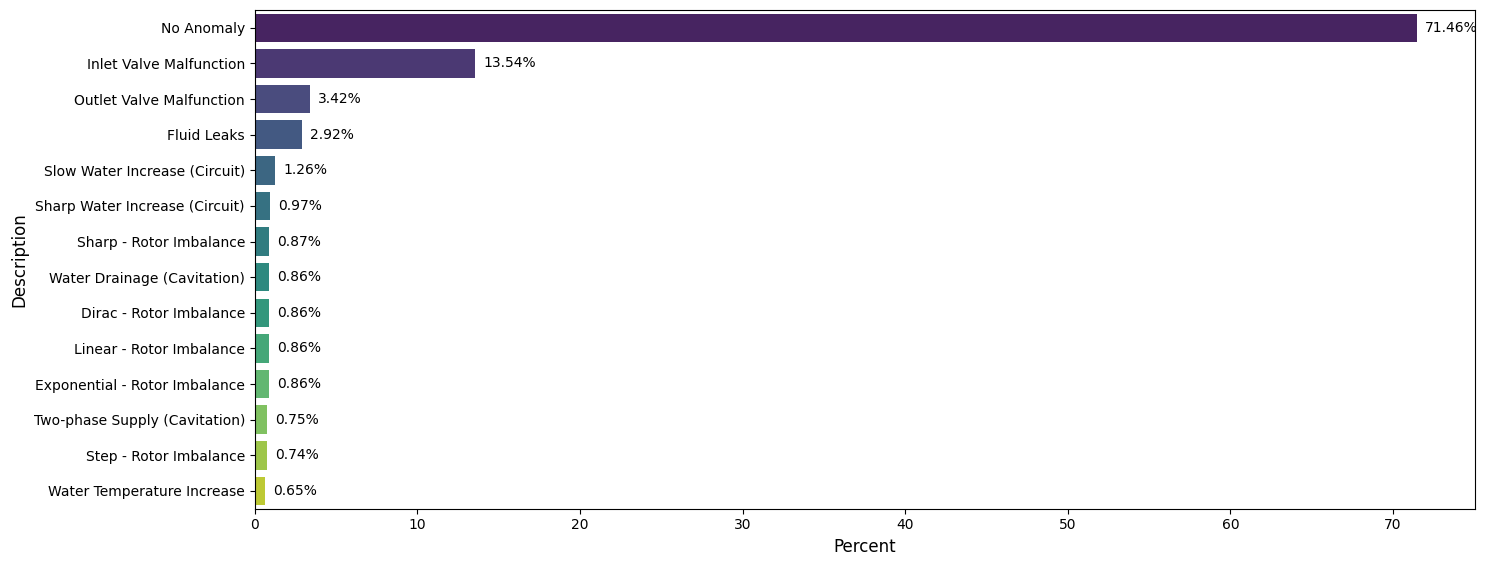

In [8]:
plot.categorical_distribution(
                                dataframe_X, 
                                column_name="description", 
                                title="Distribution_Of_Anomalies_Complete_Dataset", 
                                save=False,
)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
                                                        dataframe_X.values, 
                                                        dataframe_y.values.ravel(), 
                                                        test_size=0.3, 
                                                        random_state=SEED, 
                                                        stratify=dataframe_y.values.ravel()
)
dataframe_X_train = pd.DataFrame(X_train, columns=dataframe_X.columns)
dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
dataframe_y_train = pd.DataFrame(y_train, columns=dataframe_y.columns)
dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

X_val, X_test, y_val, y_test = train_test_split(
                                                        dataframe_X_test.values, 
                                                        dataframe_y_test.values.ravel(), 
                                                        test_size=0.5, 
                                                        random_state=SEED, 
                                                        stratify=dataframe_y_test.values.ravel()
)
dataframe_X_val = pd.DataFrame(X_val, columns=dataframe_X.columns)
dataframe_X_test = pd.DataFrame(X_test, columns=dataframe_X.columns)
dataframe_y_val = pd.DataFrame(y_val, columns=dataframe_y.columns)
dataframe_y_test = pd.DataFrame(y_test, columns=dataframe_y.columns)

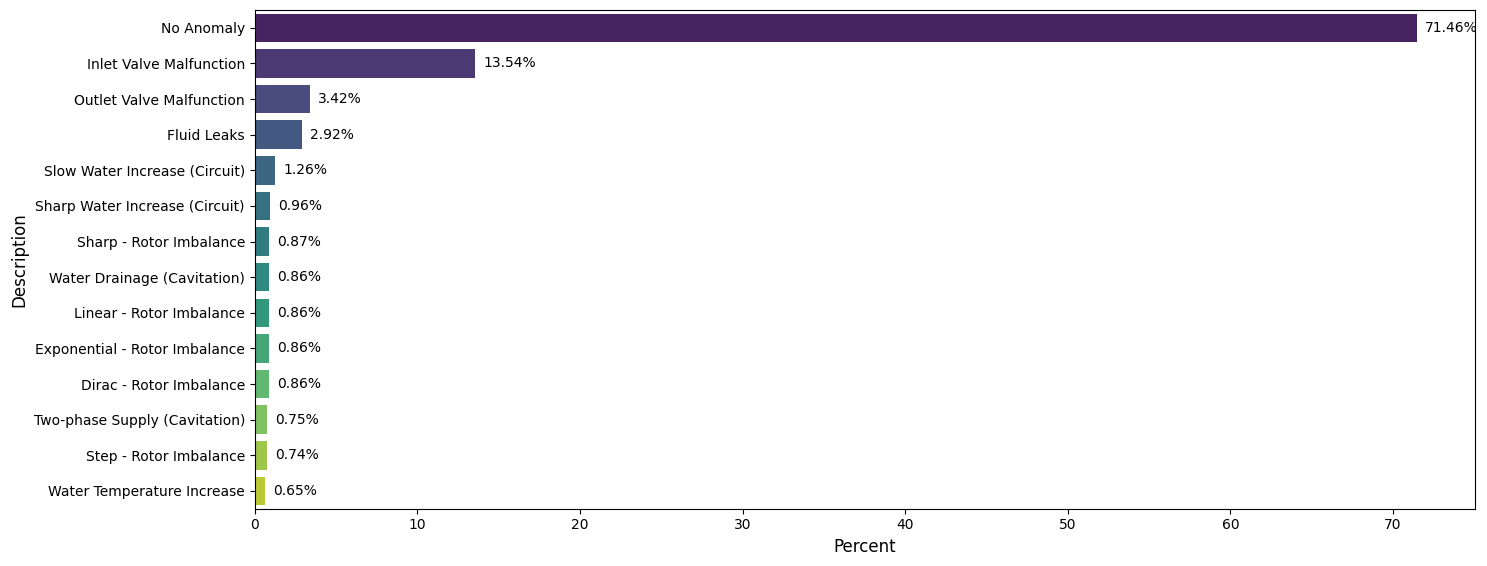

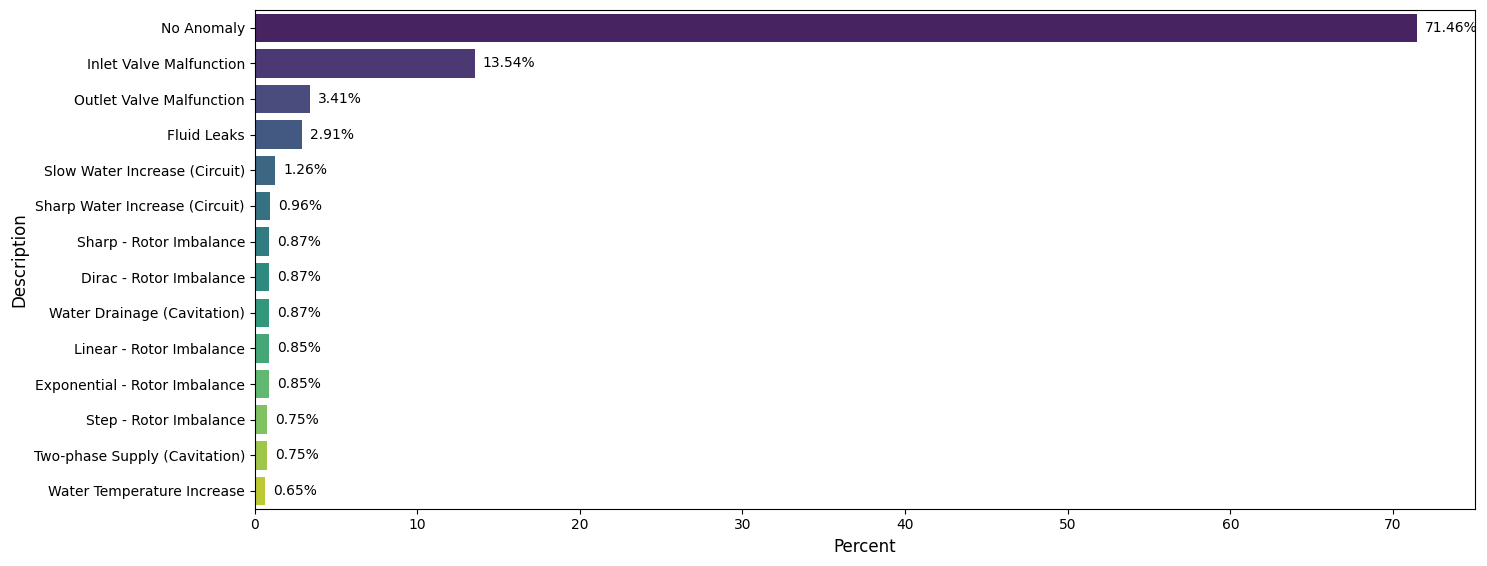

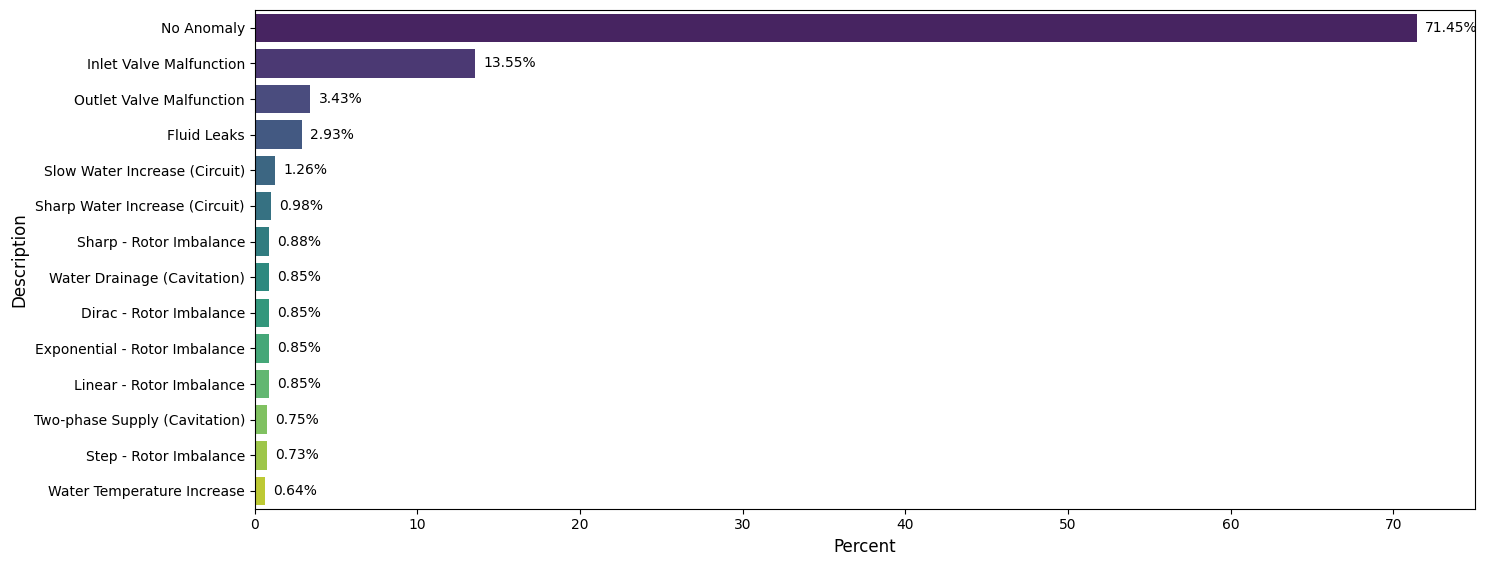

In [10]:
plot.categorical_distribution(
                                dataframe_X_train, 
                                column_name="description", 
                                title="Distribution_Of_Anomalies_Training_Set", 
                                save=False,
)
plot.categorical_distribution(
                                dataframe_X_val, 
                                column_name="description", 
                                title="Distribution_Of_Anomalies_Validation_Set", 
                                save=False,
)
plot.categorical_distribution(
                                dataframe_X_test, 
                                column_name="description", 
                                title="Distribution_Of_Anomalies_Test_Set", 
                                save=False,
)

In [11]:
pd.concat([dataframe_X_train, dataframe_y_train], axis=1).to_csv(
    "../data/preprocessed_skab_dataset_fe_train.csv", 
    index=False
)
pd.concat([dataframe_X_val, dataframe_y_val], axis=1).to_csv(
    "../data/preprocessed_skab_dataset_fe_val.csv", 
    index=False
)
pd.concat([dataframe_X_test, dataframe_y_test], axis=1).to_csv(
    "../data/preprocessed_skab_dataset_fe_test.csv", 
    index=False
)